In [ ]:
# 🌸 Project 2: Data Classification Using AI
## DecodeLabs AI Internship | Batch 2026
### Pipeline: Iris Flower Classification using KNN

Architecture: IPO Framework
- INPUT  → Iris Dataset + Feature Scaling
- PROCESS → Train/Test Split + KNN Algorithm + Elbow Tuning
- OUTPUT → Confusion Matrix + F1 Score + Live Predictor

Developer: Kashaf Kamran
Model: K-Nearest Neighbors (KNN)
Dataset: Iris Benchmark (150 samples | 3 classes | 4 features)

In [ ]:
# DATA HANDLING
import numpy as np
import pandas as pd

# MACHINE LEARNING
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
)
from sklearn.linear_model import LogisticRegression   # For model comparison

# VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# DISPLAY SETTINGS
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"]  = (10, 6)
plt.rcParams["figure.dpi"]      = 120
plt.rcParams["font.family"]     = "DejaVu Sans"
pd.set_option("display.precision", 4)

RANDOM_STATE = 42 # reproducibility

print("✅ All libraries loaded successfully.")
print(f"   NumPy    : {np.__version__}")
print(f"   Pandas   : {pd.__version__}")
print(f"   Seaborn  : {sns.__version__}")

✅ All libraries loaded successfully.
   NumPy    : 2.0.2
   Pandas   : 2.2.2
   Seaborn  : 0.13.2


In [ ]:
# LOAD DATASET
iris        = load_iris()
X           = iris.data          # Features (measurements)
y           = iris.target        # Labels (species 0, 1, 2)
features    = iris.feature_names # Column names
class_names = iris.target_names  # ['setosa', 'versicolor', 'virginica']

# CONVERT TO DATAFRAME
df         = pd.DataFrame(X, columns=features)
df["species"] = pd.Categorical.from_codes(y, class_names)

# BASIC EXPLORATION
print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"\n  Shape         : {df.shape}  (rows × columns)")
print(f"  Features      : {list(features)}")
print(f"  Target Classes: {list(class_names)}")
print(f"  Missing Values: {df.isnull().sum().sum()}")

print("\n" + "=" * 55)
print("  CLASS DISTRIBUTION (balanced = good)")
print("=" * 55)
print(df["species"].value_counts().to_string())

print("\n" + "=" * 55)
print("  FIRST 5 ROWS")
print("=" * 55)
df.head()

  DATASET OVERVIEW

  Shape         : (150, 5)  (rows × columns)
  Features      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Target Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Missing Values: 0

  CLASS DISTRIBUTION (balanced = good)
species
setosa        50
versicolor    50
virginica     50

  FIRST 5 ROWS


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("=" * 55)
print("  STATISTICAL SUMMARY (Raw — Unscaled)")
print("=" * 55)
print("\nNotice the different ranges across features:")
print("This is exactly why we MUST scale before KNN.\n")
display(df.describe().round(3))

  STATISTICAL SUMMARY (Raw — Unscaled)

Notice the different ranges across features:
This is exactly why we MUST scale before KNN.



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


Generating Pairplot — this shows all feature combinations...



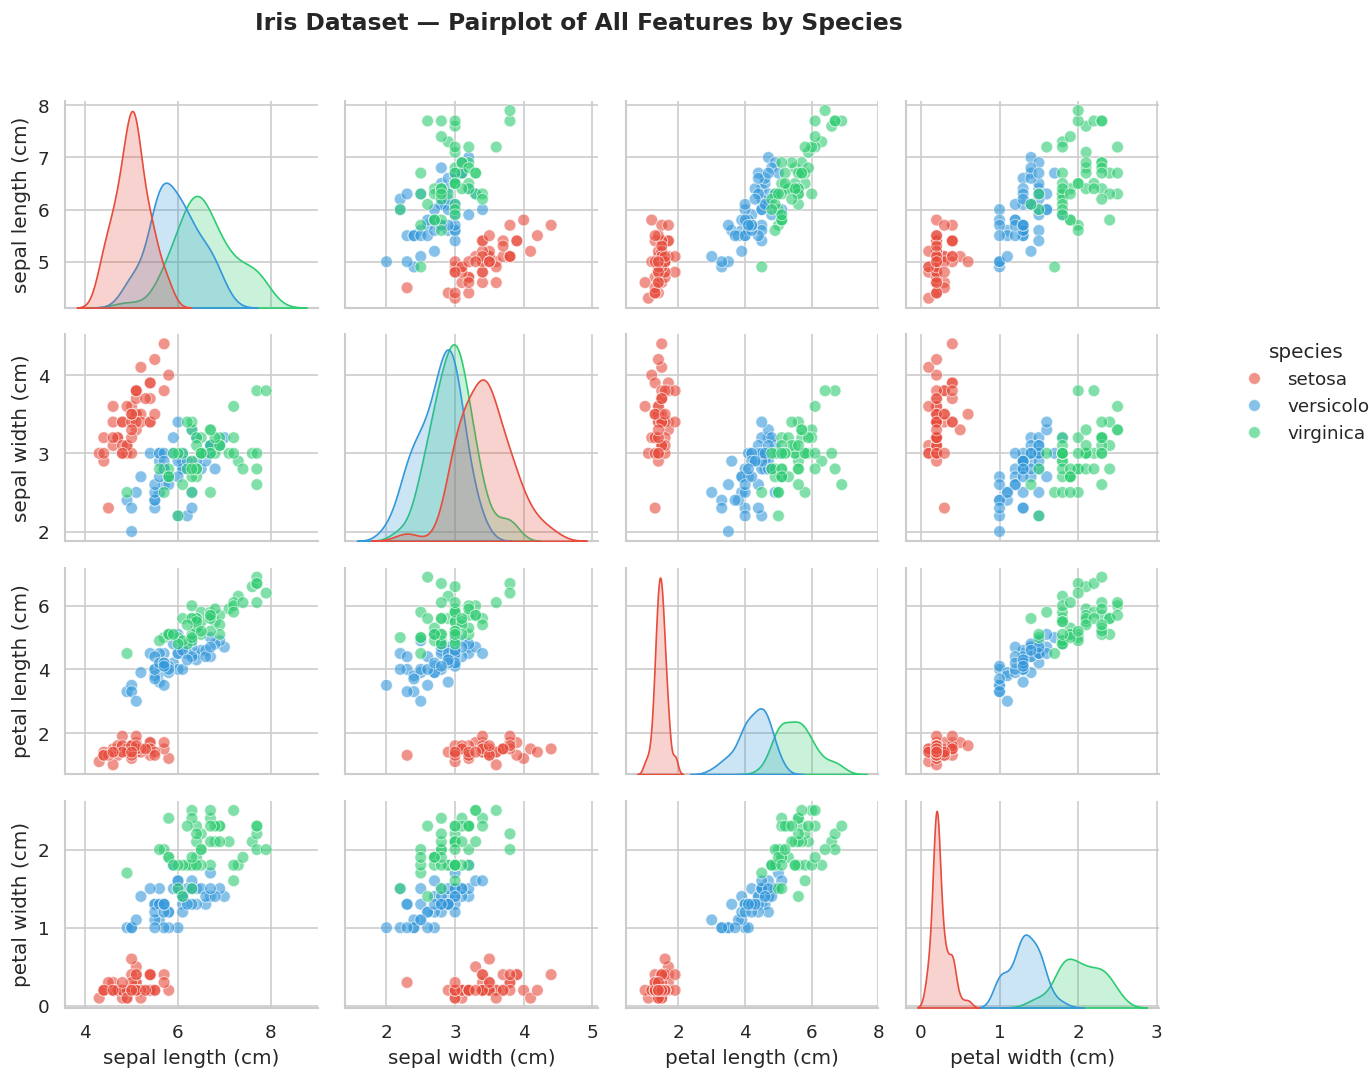


📊 KEY OBSERVATION:
   Setosa (red) is clearly separate from others.
   Versicolor & Virginica overlap slightly.
   Petal length & petal width are the most separable features.


In [ ]:
# If classes cluster separately in a plot → that
# feature is powerful for classification.

print("Generating Pairplot — this shows all feature combinations...\n")

pair_plot = sns.pairplot(
    df,
    hue        = "species",
    palette    = {"setosa": "#E74C3C", "versicolor": "#3498DB", "virginica": "#2ECC71"},
    diag_kind  = "kde",
    plot_kws   = {"alpha": 0.6, "s": 50},
    height     = 2.2,
)

pair_plot.fig.suptitle(
    "Iris Dataset — Pairplot of All Features by Species",
    y=1.02, fontsize=14, fontweight="bold"
)
pair_plot.legend.set_bbox_to_anchor((1.15, 0.65))
plt.tight_layout()
plt.savefig("pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n📊 KEY OBSERVATION:")
print("   Setosa (red) is clearly separate from others.")
print("   Versicolor & Virginica overlap slightly.")
print("   Petal length & petal width are the most separable features.")

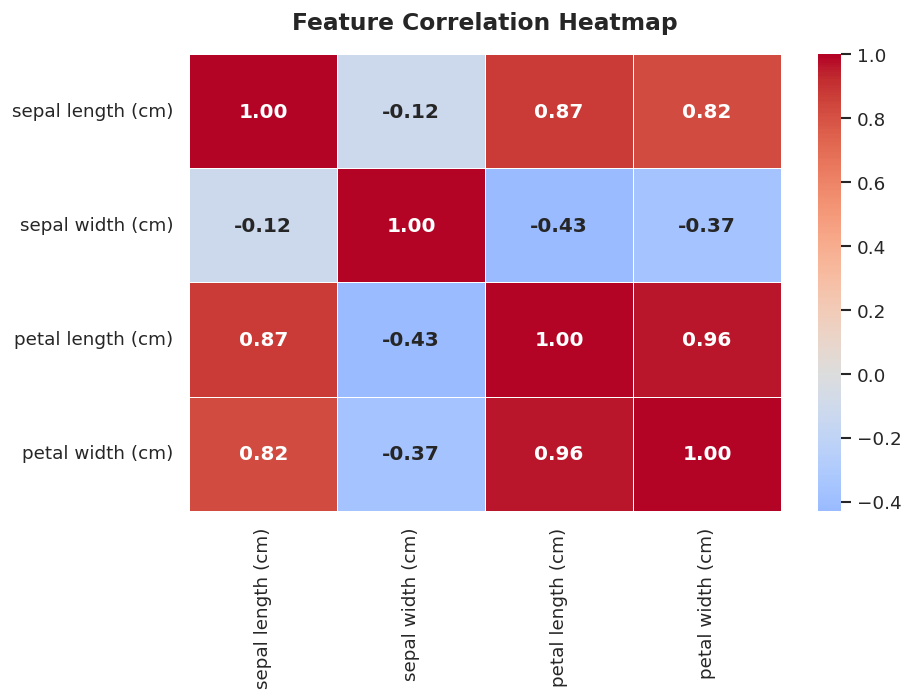


📊 KEY OBSERVATION:
   Petal length & petal width are highly correlated (0.96).
   These two features together are the strongest predictors.
   Sepal width has weak correlation with others — less useful.


In [ ]:
# High correlation (close to 1 or -1) = strong link.
# This tells us which features carry the most signal.

fig, ax = plt.subplots(figsize=(8, 6))

corr_matrix = df.drop(columns="species").corr()

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = ".2f",
    cmap       = "coolwarm",
    center     = 0,
    linewidths = 0.5,
    ax         = ax,
    annot_kws  = {"size": 12, "weight": "bold"},
)

ax.set_title(
    "Feature Correlation Heatmap",
    fontsize=14, fontweight="bold", pad=15
)

plt.tight_layout()
plt.savefig("heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n📊 KEY OBSERVATION:")
print("   Petal length & petal width are highly correlated (0.96).")
print("   These two features together are the strongest predictors.")
print("   Sepal width has weak correlation with others — less useful.")

In [ ]:
# FEATURE SCALING

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,          # 20% test, 80% train
    random_state = RANDOM_STATE, # Reproducibility
    shuffle      = True,         # Remove order bias
    stratify     = y,            # Keep class balance in both splits
)

scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit + Transform train
X_test_scaled  = scaler.transform(X_test)        # Transform only (no fit)

print("=" * 55)
print("  TRAIN / TEST SPLIT RESULTS")
print("=" * 55)
print(f"\n  Total samples  : {len(X)}")
print(f"  Training set   : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set       : {len(X_test)} samples  ({len(X_test)/len(X)*100:.0f}%)")

print("\n" + "=" * 55)
print("  SCALING VERIFICATION")
print("=" * 55)
print(f"\n  Before Scaling — Mean  : {X_train.mean(axis=0).round(3)}")
print(f"  After  Scaling — Mean  : {X_train_scaled.mean(axis=0).round(3)}")
print(f"\n  Before Scaling — StdDev: {X_train.std(axis=0).round(3)}")
print(f"  After  Scaling — StdDev: {X_train_scaled.std(axis=0).round(3)}")
print("\n  ✅ Mean ≈ 0 and StdDev ≈ 1 — Scaling confirmed.")

  TRAIN / TEST SPLIT RESULTS

  Total samples  : 150
  Training set   : 120 samples (80%)
  Test set       : 30 samples  (20%)

  SCALING VERIFICATION

  Before Scaling — Mean  : [5.842 3.048 3.77  1.205]
  After  Scaling — Mean  : [-0. -0.  0.  0.]

  Before Scaling — StdDev: [0.837 0.447 1.761 0.759]
  After  Scaling — StdDev: [1. 1. 1. 1.]

  ✅ Mean ≈ 0 and StdDev ≈ 1 — Scaling confirmed.


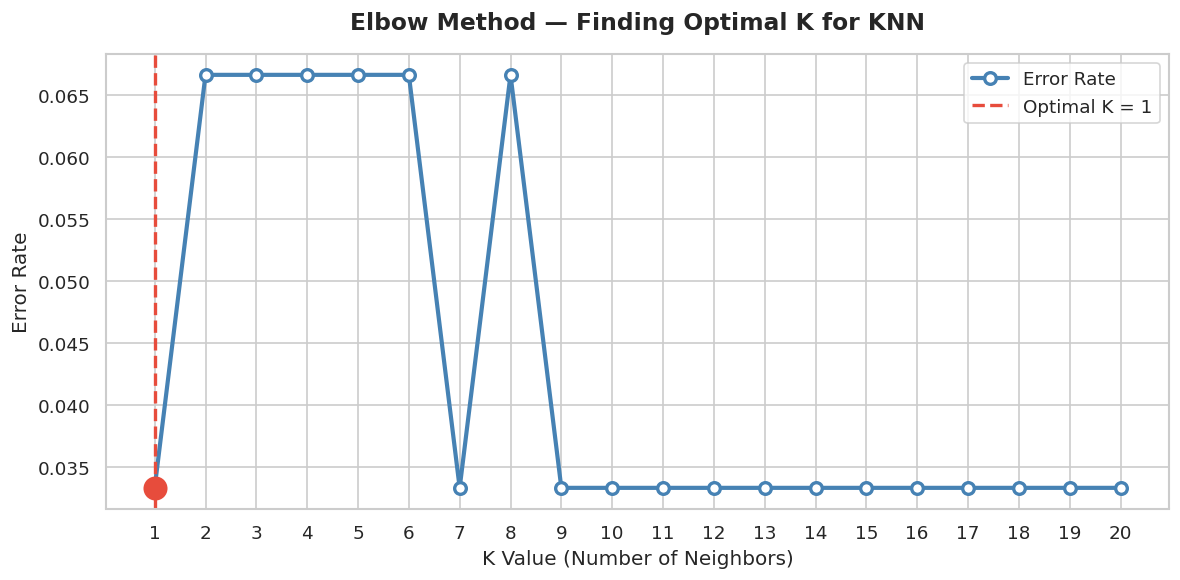


🎯 Optimal K found: 1
   Error Rate at K=1: 0.0333
   Accuracy at K=1  : 96.67%


In [ ]:
# K=1  → Overfitting (memorizes training data, fails on new)
# K=100→ Underfitting (too general, ignores patterns)
# Elbow→ The sweet spot where error is minimum

error_rates = []
k_range     = range(1, 21)

for k in k_range:
    knn   = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, preds)
    error_rates.append(error)

optimal_k   = k_range[error_rates.index(min(error_rates))]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    k_range, error_rates,
    color="steelblue", linewidth=2.5,
    marker="o", markersize=7, markerfacecolor="white",
    markeredgewidth=2, label="Error Rate"
)

# Highlight the optimal K
ax.axvline(
    x=optimal_k, color="#E74C3C",
    linestyle="--", linewidth=2,
    label=f"Optimal K = {optimal_k}"
)
ax.scatter(
    [optimal_k], [error_rates[optimal_k - 1]],
    color="#E74C3C", s=180, zorder=5
)

ax.set_title("Elbow Method — Finding Optimal K for KNN",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("K Value (Number of Neighbors)", fontsize=12)
ax.set_ylabel("Error Rate", fontsize=12)
ax.legend(fontsize=11)
ax.set_xticks(list(k_range))

plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n🎯 Optimal K found: {optimal_k}")
print(f"   Error Rate at K={optimal_k}: {error_rates[optimal_k-1]:.4f}")
print(f"   Accuracy at K={optimal_k}  : {(1-error_rates[optimal_k-1])*100:.2f}%")

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors = optimal_k,
    metric      = "euclidean",  # Distance formula used
    weights     = "uniform",    # All neighbors vote equally
)

knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 55)
print(f"  KNN MODEL TRAINED SUCCESSFULLY")
print("=" * 55)
print(f"\n  K (neighbors)  : {optimal_k}")
print(f"  Distance metric: Euclidean")
print(f"  Training size  : {len(X_train)} samples")
print(f"  Test size      : {len(X_test)} samples")
print(f"\n  Raw Accuracy   : {accuracy*100:.2f}%")
print(f"\n  ⚠  Note: Accuracy alone can be misleading.")
print(f"     See Confusion Matrix & F1 Score below.")

  KNN MODEL TRAINED SUCCESSFULLY

  K (neighbors)  : 1
  Distance metric: Euclidean
  Training size  : 120 samples
  Test size      : 30 samples

  Raw Accuracy   : 96.67%

  ⚠  Note: Accuracy alone can be misleading.
     See Confusion Matrix & F1 Score below.


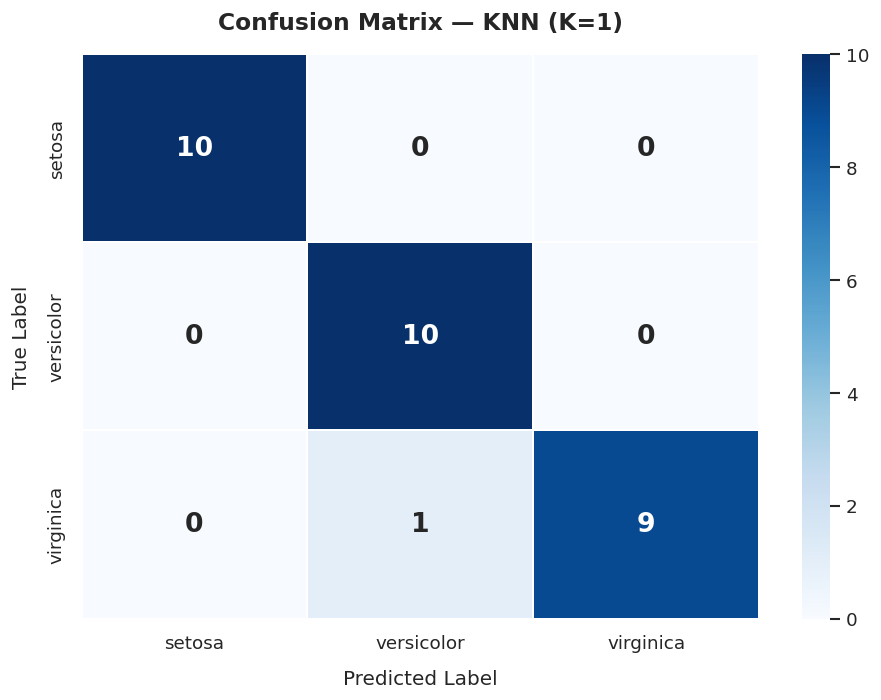


  CONFUSION MATRIX BREAKDOWN

  SETOSA
    True Positives  (TP): 10  ← Correctly identified
    False Negatives (FN): 0  ← Missed (called something else)
    False Positives (FP): 0  ← Wrong alarm (called this by mistake)

  VERSICOLOR
    True Positives  (TP): 10  ← Correctly identified
    False Negatives (FN): 0  ← Missed (called something else)
    False Positives (FP): 1  ← Wrong alarm (called this by mistake)

  VIRGINICA
    True Positives  (TP): 9  ← Correctly identified
    False Negatives (FN): 1  ← Missed (called something else)
    False Positives (FP): 0  ← Wrong alarm (called this by mistake)


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot       = True,
    fmt         = "d",
    cmap        = "Blues",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 1,
    linecolor   = "white",
    annot_kws   = {"size": 16, "weight": "bold"},
    ax          = ax,
)

ax.set_title(
    f"Confusion Matrix — KNN (K={optimal_k})",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("True Label",      fontsize=12, labelpad=10)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n" + "=" * 55)
print("  CONFUSION MATRIX BREAKDOWN")
print("=" * 55)
for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    print(f"\n  {class_name.upper()}")
    print(f"    True Positives  (TP): {tp}  ← Correctly identified")
    print(f"    False Negatives (FN): {fn}  ← Missed (called something else)")
    print(f"    False Positives (FP): {fp}  ← Wrong alarm (called this by mistake)")

In [ ]:
f1     = f1_score(y_test, y_pred, average="weighted")
report = classification_report(y_test, y_pred, target_names=class_names)

print("=" * 55)
print("  FULL CLASSIFICATION REPORT")
print("=" * 55)
print(report)

print("=" * 55)
print("  SUMMARY SCORES")
print("=" * 55)
print(f"\n  Accuracy       : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  F1 Score       : {f1*100:.2f}%  ← The honest metric")
print(f"\n  Interpretation:")
if f1 >= 0.95:
    print("  ✅ EXCELLENT — Model performs very well across all classes.")
elif f1 >= 0.85:
    print("  ✅ GOOD — Model is solid, minor room for improvement.")
elif f1 >= 0.70:
    print("  ⚠  FAIR — Model needs tuning or more data.")
else:
    print("  ❌ POOR — Model needs significant improvement.")

  FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

  SUMMARY SCORES

  Accuracy       : 96.67%
  F1 Score       : 96.66%  ← The honest metric

  Interpretation:
  ✅ EXCELLENT — Model performs very well across all classes.


  MODEL COMPARISON TABLE


,Accuracy (%),F1 Score (%)
KNN (Optimal K),96.67,96.66
Logistic Regression,93.33,93.33


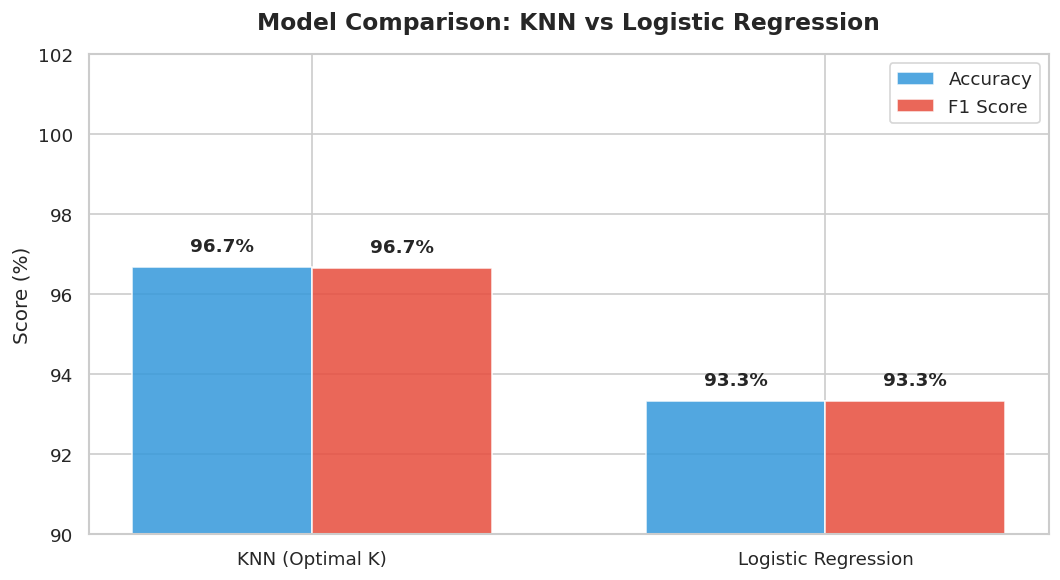

In [ ]:
# MODEL COMPARISON

models = {
    "KNN (Optimal K)"     : KNeighborsClassifier(n_neighbors=optimal_k),
    "Logistic Regression" : LogisticRegression(
                                max_iter=500,
                                random_state=RANDOM_STATE
                            ),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds      = model.predict(X_test_scaled)
    acc        = accuracy_score(y_test, preds)
    f1_val     = f1_score(y_test, preds, average="weighted")
    results[name] = {"Accuracy": acc, "F1 Score": f1_val}

results_df = pd.DataFrame(results).T * 100
results_df = results_df.round(2)
results_df.columns = ["Accuracy (%)", "F1 Score (%)"]

print("=" * 55)
print("  MODEL COMPARISON TABLE")
print("=" * 55)
display(results_df)

fig, ax = plt.subplots(figsize=(9, 5))

x      = np.arange(len(results_df))
width  = 0.35
bars1  = ax.bar(x - width/2, results_df["Accuracy (%)"],
                width, label="Accuracy", color="#3498DB", alpha=0.85)
bars2  = ax.bar(x + width/2, results_df["F1 Score (%)"],
                width, label="F1 Score", color="#E74C3C", alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Model Comparison: KNN vs Logistic Regression",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim([90, 102])
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# LIVE FLOWER PREDICTOR

def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    """
    Takes raw flower measurements and returns predicted species.
    Automatically applies the same scaling used during training.
    """
    # Package input as array
    sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    # Scale using the SAME scaler fitted on training data
    sample_scaled = scaler.transform(sample)

    # Predict
    prediction    = knn_model.predict(sample_scaled)[0]
    probabilities = knn_model.predict_proba(sample_scaled)[0]
    species_name  = class_names[prediction]

    print("=" * 50)
    print("  🌸 FLOWER SPECIES PREDICTOR")
    print("=" * 50)
    print(f"\n  Input Measurements:")
    print(f"    Sepal Length : {sepal_length} cm")
    print(f"    Sepal Width  : {sepal_width} cm")
    print(f"    Petal Length : {petal_length} cm")
    print(f"    Petal Width  : {petal_width} cm")
    print(f"\n  Prediction    : 🌺 {species_name.upper()}")
    print(f"\n  Confidence Breakdown:")
    for i, name in enumerate(class_names):
        bar    = "█" * int(probabilities[i] * 20)
        spaces = "░" * (20 - int(probabilities[i] * 20))
        print(f"    {name:<12} [{bar}{spaces}] {probabilities[i]*100:.1f}%")
    print("=" * 50)
    return species_name


print("TEST 1 — Known Setosa:")
predict_flower(5.1, 3.5, 1.4, 0.2)

print("\nTEST 2 — Known Versicolor:")
predict_flower(6.0, 2.9, 4.5, 1.5)

print("\nTEST 3 — Known Virginica:")
predict_flower(6.7, 3.1, 5.6, 2.4)

TEST 1 — Known Setosa:
  🌸 FLOWER SPECIES PREDICTOR

  Input Measurements:
    Sepal Length : 5.1 cm
    Sepal Width  : 3.5 cm
    Petal Length : 1.4 cm
    Petal Width  : 0.2 cm

  Prediction    : 🌺 SETOSA

  Confidence Breakdown:
    setosa       [████████████████████] 100.0%
    versicolor   [░░░░░░░░░░░░░░░░░░░░] 0.0%
    virginica    [░░░░░░░░░░░░░░░░░░░░] 0.0%

TEST 2 — Known Versicolor:
  🌸 FLOWER SPECIES PREDICTOR

  Input Measurements:
    Sepal Length : 6.0 cm
    Sepal Width  : 2.9 cm
    Petal Length : 4.5 cm
    Petal Width  : 1.5 cm

  Prediction    : 🌺 VERSICOLOR

  Confidence Breakdown:
    setosa       [░░░░░░░░░░░░░░░░░░░░] 0.0%
    versicolor   [████████████████████] 100.0%
    virginica    [░░░░░░░░░░░░░░░░░░░░] 0.0%

TEST 3 — Known Virginica:
  🌸 FLOWER SPECIES PREDICTOR

  Input Measurements:
    Sepal Length : 6.7 cm
    Sepal Width  : 3.1 cm
    Petal Length : 5.6 cm
    Petal Width  : 2.4 cm

  Prediction    : 🌺 VIRGINICA

  Confidence Breakdown:
    setosa    

np.str_('virginica')

In [ ]:
# YOUR OWN PREDICTION
# Change the 4 numbers below to any measurements you want!
# Typical ranges:
#   Sepal Length: 4.0 – 8.0 cm
#   Sepal Width : 2.0 – 4.5 cm
#   Petal Length: 1.0 – 7.0 cm
#   Petal Width : 0.1 – 2.5 cm

predict_flower(
    sepal_length = 5.8,   # ← Change this
    sepal_width  = 3.0,   # ← Change this
    petal_length = 4.8,   # ← Change this
    petal_width  = 1.8,   # ← Change this
)

  🌸 FLOWER SPECIES PREDICTOR

  Input Measurements:
    Sepal Length : 5.8 cm
    Sepal Width  : 3.0 cm
    Petal Length : 4.8 cm
    Petal Width  : 1.8 cm

  Prediction    : 🌺 VIRGINICA

  Confidence Breakdown:
    setosa       [░░░░░░░░░░░░░░░░░░░░] 0.0%
    versicolor   [░░░░░░░░░░░░░░░░░░░░] 0.0%
    virginica    [████████████████████] 100.0%


np.str_('virginica')